<a href="https://colab.research.google.com/github/neilvzx/predictive-maintenance-ml/blob/main/priceofcars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder


In [ ]:
# Load the dataset
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/usedCars.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    Id               1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


# New Section

In [ ]:
# Data Cleaning and Feature Engineering

# Drop rows with missing values in essential columns
df = df.dropna(subset=['Company', 'ModelYear', 'Kilometer', 'Owner', 'BodyStyle', 'Price'])

# Convert 'Price' to numeric (assuming it's in 'X.XX Lakhs' format)
def parse_price(price_str):
    if isinstance(price_str, str):
        price_str = price_str.replace(' Lakhs', '').strip()
        try:
            # Convert to float and then multiply by 100000 for actual value in Rupees
            return float(price_str) * 100000
        except ValueError:
            return np.nan # Handle cases that don't fit the expected format
    return price_str # Return non-string values as is

df['Price'] = df['Price'].apply(parse_price)

# Drop rows where Price could not be converted
df = df.dropna(subset=['Price'])

# Create 'Car_Age' feature
df['Car_Age'] = 2023 - df['ModelYear']

# Convert 'Warranty' and 'CngKit' to numerical (assuming 'Yes'/'No' or similar)
# Based on df.info(), these columns might have NaNs and need handling
# We'll map 'Yes' to 1, 'No' to 0, and fill NaNs with 0
df['Warranty'] = df['Warranty'].map({'Yes': 1, 'No': 0}).fillna(0)
df['CngKit'] = df['CngKit'].map({'Yes': 1, 'No': 0}).fillna(0)


print("\nData after cleaning and feature engineering:")
print(df.info())
display(df.head())


Data after cleaning and feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 1063 entries, 0 to 1063
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    Id               1063 non-null   int64  
 1   Company           1063 non-null   object 
 2   Model             1063 non-null   object 
 3   Variant           1063 non-null   object 
 4   FuelType          1062 non-null   object 
 5   Colour            1063 non-null   object 
 6   Kilometer         1063 non-null   int64  
 7   BodyStyle         1063 non-null   object 
 8   TransmissionType  349 non-null    object 
 9   ManufactureDate   1063 non-null   object 
 10  ModelYear         1063 non-null   int64  
 11  CngKit            1063 non-null   float64
 12  Price             1063 non-null   float64
 13  Owner             1063 non-null   object 
 14  DealerState       1063 non-null   object 
 15  DealerName        1063 non-null   object 
 16  C

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore,Car_Age
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,01-02-2018,2018,0.0,575000.0,1st Owner,Karnataka,Top Gear Cars,Bangalore,0.0,7.8,5
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,01-03-2021,2021,0.0,435000.0,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,0.0,8.3,2
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,01-03-2015,2015,0.0,470000.0,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,0.0,7.9,8
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,01-08-2020,2020,0.0,990000.0,1st Owner,Karnataka,Adeep Motors,Bangalore,0.0,8.1,3
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,01-11-2010,2010,0.0,270000.0,2nd Owner,Karnataka,Zippy Automart,Bangalore,0.0,7.5,13


In [ ]:
# One-Hot Encode categorical features, including 'Owner' and 'TransmissionType'
# Handling TransmissionType NaNs by treating NaN as a category or filling before encoding
# Let's fill NaN in TransmissionType with a placeholder like 'Unknown' before encoding
df['TransmissionType'] = df['TransmissionType'].fillna('Unknown')

categorical_cols = ['Company', 'FuelType', 'Colour', 'BodyStyle', 'TransmissionType', 'Owner']
# Ensure columns exist before encoding to avoid errors
categorical_cols_existing = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=categorical_cols_existing, drop_first=True)

print("\nData after one-hot encoding:")
print(df.info())
display(df.head())


Data after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 1063 entries, 0 to 1063
Columns: 136 entries,  Id  to Owner_4th Owner
dtypes: bool(122), float64(4), int64(4), object(6)
memory usage: 251.2+ KB
None


,Id,Model,Variant,Kilometer,ManufactureDate,ModelYear,CngKit,Price,DealerState,DealerName,...,TransmissionType_Automatic,TransmissionType_Cvt,TransmissionType_M,TransmissionType_MANUAL,TransmissionType_Manual,TransmissionType_Unknown,TransmissionType_manual,Owner_2nd Owner,Owner_3rd Owner,Owner_4th Owner
0,555675,CELERIO(2017-2019),1.0 ZXI AMT O,33197,01-02-2018,2018,0.0,575000.0,Karnataka,Top Gear Cars,...,False,False,False,False,False,True,False,False,False,False
1,556383,ALTO,LXI,10322,01-03-2021,2021,0.0,435000.0,Karnataka,Renew 4 u Automobiles PVT Ltd,...,False,False,False,False,True,False,False,False,False,False
2,556422,GRAND I10,1.2 KAPPA ASTA,37889,01-03-2015,2015,0.0,470000.0,Karnataka,Anant Cars Auto Pvt Ltd,...,False,False,False,False,True,False,False,False,False,False
3,556771,NEXON,XT PLUS,13106,01-08-2020,2020,0.0,990000.0,Karnataka,Adeep Motors,...,False,False,False,False,False,True,False,False,False,False
4,559619,FIGO,EXI DURATORQ 1.4,104614,01-11-2010,2010,0.0,270000.0,Karnataka,Zippy Automart,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
# Define features (X) and target (y)

# Collect all one-hot encoded columns and other numerical features
# Ensure all columns used for feature selection exist after one-hot encoding
all_possible_feature_prefixes = ('Company_', 'FuelType_', 'Colour_', 'BodyStyle_', 'TransmissionType_', 'Owner_')
one_hot_encoded_cols = [col for col in df.columns if col.startswith(all_possible_feature_prefixes)]

numerical_features = ['Car_Age', 'Kilometer', 'CngKit', 'Warranty', 'QualityScore']
numerical_features_existing = [col for col in numerical_features if col in df.columns]


feature_cols = one_hot_encoded_cols + numerical_features_existing

# Ensure all feature columns actually exist in the DataFrame
feature_cols_existing = [col for col in feature_cols if col in df.columns]

X = df[feature_cols_existing]
y = df['Price']

print("\nFeatures (X) and Target (y) created.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
display(X.head())
display(y.head())


Features (X) and Target (y) created.
Shape of X: (1063, 127)
Shape of y: (1063,)


,Company_BMW,Company_CHEVROLET,Company_DATSUN,Company_FIAT,Company_FORD,Company_HONDA,Company_HYUNDAI,Company_ISUZU,Company_JEEP,Company_KIA,...,TransmissionType_Unknown,TransmissionType_manual,Owner_2nd Owner,Owner_3rd Owner,Owner_4th Owner,Car_Age,Kilometer,CngKit,Warranty,QualityScore
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,5,33197,0.0,0.0,7.8
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,2,10322,0.0,0.0,8.3
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,8,37889,0.0,0.0,7.9
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,3,13106,0.0,0.0,8.1
4,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,13,104614,0.0,0.0,7.5


,Price
0,575000.0
1,435000.0
2,470000.0
3,990000.0
4,270000.0


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets.")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Data split into training and testing sets.
Shape of X_train: (850, 127)
Shape of X_test: (213, 127)
Shape of y_train: (850,)
Shape of y_test: (213,)


In [ ]:
# Train the RandomForestRegressor model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

try:
    rf.fit(X_train, y_train)
    print("\nRandomForestRegressor model trained successfully!")
except Exception as e:
    print(f"An error occurred during model training: {e}")


RandomForestRegressor model trained successfully!


In [ ]:
# Evaluate the model
try:
    y_pred = rf.predict(X_test)
    print("Model Evaluation:")
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("R^2 Score:", r2_score(y_test, y_pred))
except Exception as e:
    print(f"An error occurred during model evaluation: {e}")

Model Evaluation:
Mean Absolute Error: 183067.04225352113
R^2 Score: 0.649610136195844


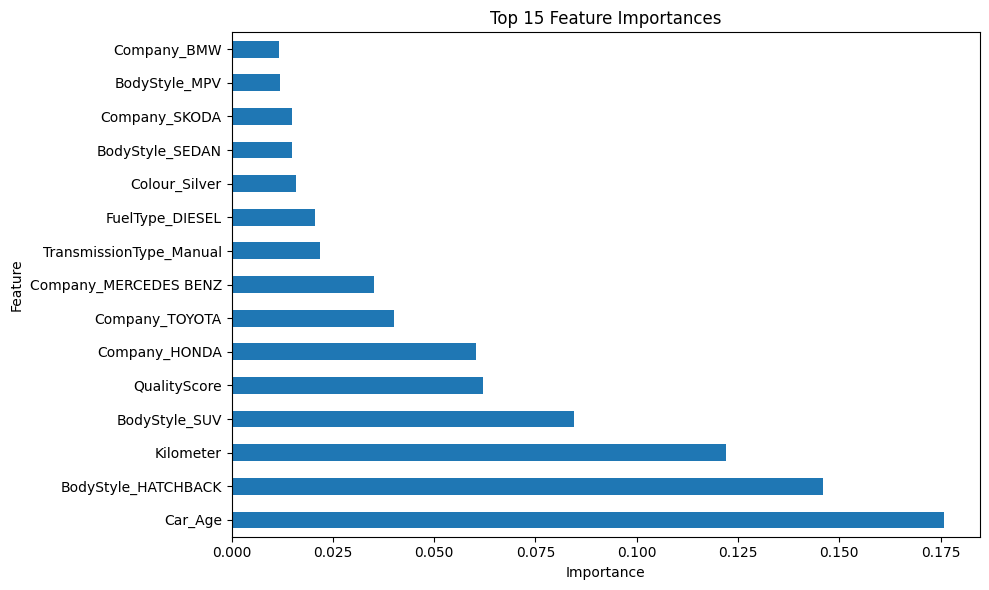


Function to predict new car price defined.

Predicted price for the example car: 665610.00 Rupees
Predicted price for the example car: 6.66 Lakhs


In [ ]:
import matplotlib.pyplot as plt

# Display Feature Importances
try:
    if hasattr(rf, 'feature_importances_'):
        feat_imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(15)
        plt.figure(figsize=(10, 6))
        feat_imp.plot(kind='barh')
        plt.title("Top 15 Feature Importances")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
    else:
        print("Feature importances are not available for this model.")

except Exception as e:
    print(f"An error occurred while plotting feature importances: {e}")


# Function for New Car Prediction
def predict_price(new_car_dict, model, feature_columns):
    """
    Predicts the price of a new car using the trained model.

    Args:
        new_car_dict (dict): Dictionary matching input features of the new car.
                             Keys should match the column names used for training (feature_columns).
        model: The trained machine learning model (e.g., RandomForestRegressor).
        feature_columns (pd.Index): The index of feature columns used during training (X.columns).

    Returns:
        float: Predicted price of the car.
    """
    # Create a DataFrame for the new input, ensuring all training columns are present
    inp = pd.DataFrame([new_car_dict])

    # Add any missing feature columns from the training data, filling with 0
    for col in feature_columns:
        if col not in inp.columns:
            inp[col] = 0

    # Ensure the columns are in the same order as the training data
    inp = inp[feature_columns]

    # Predict the price
    predicted_price = model.predict(inp)[0]
    return predicted_price

print("\nFunction to predict new car price defined.")

# Example usage of the prediction function
# This example assumes a car with certain characteristics;
# you'll need to create a dictionary that matches the features (especially one-hot encoded ones)
# of the new car you want to predict the price for.

# Example input dictionary (ensure it matches the structure of X.columns)
# You need to set the appropriate one-hot encoded columns to 1 and others to 0
example_new_car_data = dict.fromkeys(X.columns, 0)

# Fill in the details for the example car
example_new_car_data.update({
    'Car_Age': 3,          # Example: 3 years old
    'Kilometer': 30000,    # Example: 30,000 km driven
    'CngKit': 0,           # Example: No CNG kit
    'Warranty': 1,         # Example: Has warranty
    'QualityScore': 8.5,   # Example: Quality score of 8.5

    # Example: Assuming it's a Maruti car (one-hot encoded)
    'Company_MARUTI': 1,

    # Example: Assuming it's a Petrol car
    'FuelType_PETROL': 1,

    # Example: Assuming the color is White
    'Colour_White': 1,

    # Example: Assuming it's a Hatchback
    'BodyStyle_HATCHBACK': 1,

    # Example: Assuming Manual transmission
    'TransmissionType_MANUAL': 1,

    # Example: Assuming 1st Owner (assuming 'Owner_1.0' if one-hot encoded based on integer owner type)
    # Check your X.columns to see the exact name for the 'Owner' dummy variable
    # Based on your df.info() after one-hot encoding, it looks like Owner_2.0, Owner_3.0, Owner_4.0 exist.
    # If 1st Owner is the baseline (drop_first=True), you might not need to set a specific Owner_ column to 1.
    # If '1st Owner' was one of the values and was encoded, adjust the key accordingly (e.g., 'Owner_1st Owner': 1).
    # Let's assume '1st Owner' is the baseline for this example, so no Owner_ column is set to 1.
    # If 'Owner_1.0' exists, use 'Owner_1.0': 1 instead.
})

# Ensure the example dictionary only contains columns present in X.columns
example_input_filtered = {k: v for k, v in example_new_car_data.items() if k in X.columns}

if not example_input_filtered:
    print("Example input data is empty or does not match feature columns.")
else:
    try:
        predicted_price_example = predict_price(example_input_filtered, rf, X.columns)
        print(f"\nPredicted price for the example car: {predicted_price_example:.2f} Rupees")
        print(f"Predicted price for the example car: {predicted_price_example/100000:.2f} Lakhs")
    except Exception as e:
        print(f"An error occurred during example prediction: {e}")